### Word Recognition Model

1. Install the required Python packages

In [6]:
# Load libraries
import librosa #MFCC feature extraction
import sklearn
import librosa
import os
import numpy as np
import matplotlib as plt
import seaborn as sns
import joblib
import soundfile
import subprocess
from pydub import AudioSegment

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam


print(tf.__version__)
print(librosa.__version__)


2.21.0
0.11.0


Creating a dataset loader

In [7]:
DATASET_PATH = Path("SoundsData")

records = []

# Each subfolder represents a word in SoundData folder. Each subfolder contains .wav files of that word. 
for word_folder in DATASET_PATH.iterdir():
    if not word_folder.is_dir():
        continue
    word = word_folder.name
    wav_files = list(word_folder.glob("*.wav"))
    print(f"{word}: {len(wav_files)} files")
    for wav_file in wav_files:
        try:
            audio, sample_rate = librosa.load(
                wav_file,
                sr=16000, # Resample to 16 kHz
                mono=True
            )

            duration = len(audio) / sample_rate
            records.append({
                "word": word,
                "file": wav_file.name,
                "sample_rate": sample_rate,
                "duration": duration,
                "samples": len(audio)
            })

        except Exception as e:
            print(f"ERROR: {wav_file}")
            print(e)

bed: 1713 files
bird: 1731 files
cat: 1733 files
dog: 1746 files
down: 2359 files
eight: 2352 files
five: 2357 files
four: 2372 files
go: 2372 files
happy: 1742 files
house: 1750 files
left: 2353 files
marvin: 1746 files
nine: 2364 files
no: 2375 files
off: 2357 files
on: 2367 files
one: 2370 files
right: 2367 files
seven: 2377 files
sheila: 1734 files
six: 2369 files
stop: 2380 files
three: 2356 files
tree: 1733 files
two: 2373 files
up: 2375 files
wow: 1745 files
yes: 2377 files
zero: 2376 files


Add the extracted records detail to a dataframe 

In [8]:
# Convert to DataFrame
df = pd.DataFrame(records)

print("DATASET SUMMARY")
print(f"Total WAV files: {len(df)}")
print(f"Number of words: {df['word'].nunique()}")

print("\nFiles per word:")
print(df["word"].value_counts().sort_index())

# Duplicate files check
duplicate_files = df[df.duplicated(subset=["file"], keep=False)]
print(f"\nDuplicate files found: {len(duplicate_files)}")

print("\nDuration statistics:")
print(df["duration"].describe())

DATASET SUMMARY
Total WAV files: 64721
Number of words: 30

Files per word:
word
bed       1713
bird      1731
cat       1733
dog       1746
down      2359
eight     2352
five      2357
four      2372
go        2372
happy     1742
house     1750
left      2353
marvin    1746
nine      2364
no        2375
off       2357
on        2367
one       2370
right     2367
seven     2377
sheila    1734
six       2369
stop      2380
three     2356
tree      1733
two       2373
up        2375
wow       1745
yes       2377
zero      2376
Name: count, dtype: int64

Duplicate files found: 63617

Duration statistics:
count    64721.000000
mean         0.984582
std          0.059484
min          0.371563
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: duration, dtype: float64


Loading: SoundsData/Four\00f0204f_nohash_0.wav
Loading: SoundsData/Go\00f0204f_nohash_0.wav


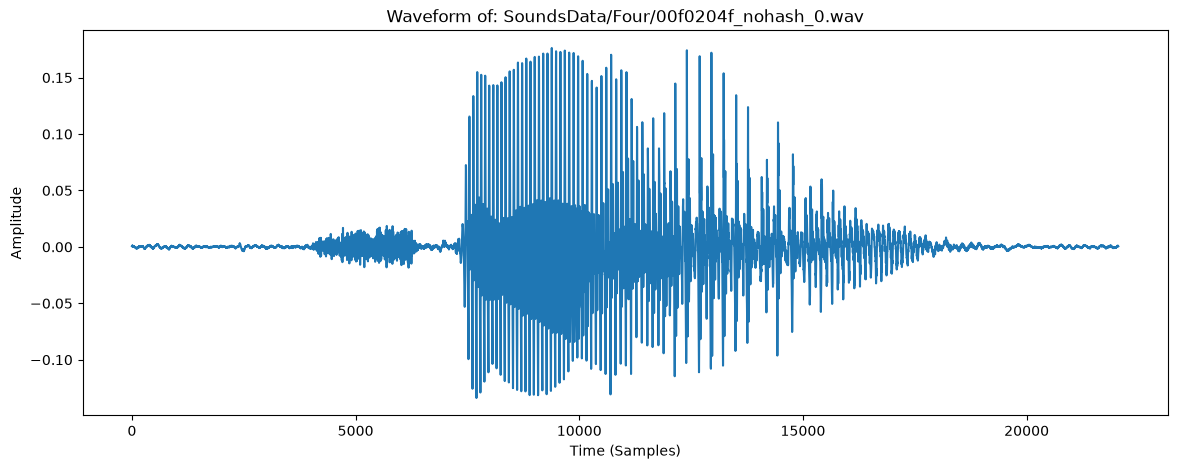

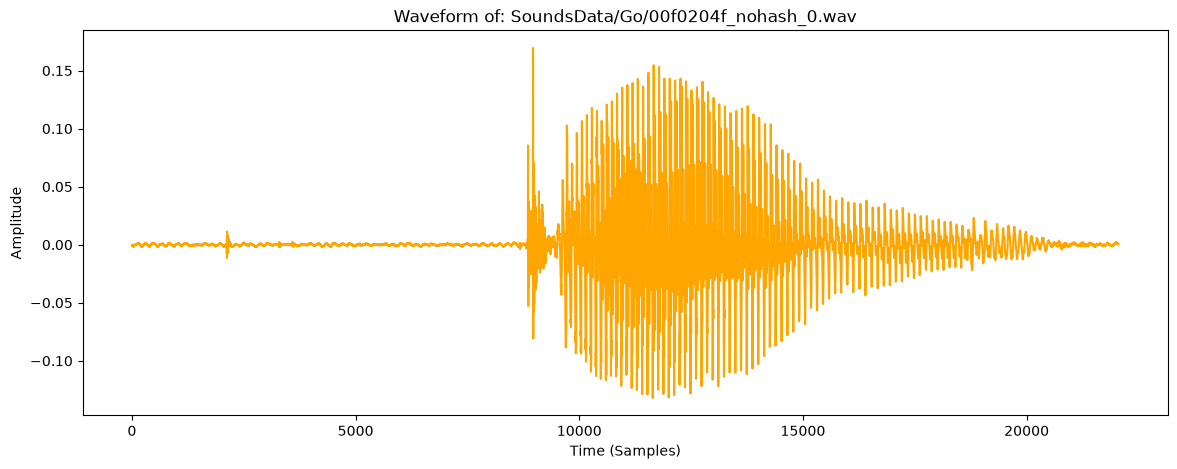

In [9]:
# Display a testing audio files sound waves for two different words to see if they are similar or not for the same speaker.

folder_path = 'SoundsData/Four'
file_name = '00f0204f_nohash_0.wav' #File name represents the identical speaker
audio_path = os.path.join(folder_path, file_name)
print(f"Loading: {audio_path}")
y, sr = librosa.load(audio_path)

folder_path2 = 'SoundsData/Go'
file_name2 = '00f0204f_nohash_0.wav'
audio_path2 = os.path.join(folder_path2, file_name2)
print(f"Loading: {audio_path2}")
y2, sr2 = librosa.load(audio_path2)

# Plot the waveform
plt.figure(figsize=(14, 5))
plt.plot(y)
plt.title(f'Waveform of: {folder_path}/{file_name}')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude')
plt.show()

# Plot the waveform2
plt.figure(figsize=(14, 5))
plt.plot(y2,color='orange')
plt.title(f'Waveform of: {folder_path2}/{file_name2}')
plt.xlabel('Time (Samples)')
plt.ylabel('Amplitude')
plt.show()

Based on the above value counts by classed it can be clearly seen there's class imbalance in dataset

In [10]:
df.head()

,word,file,sample_rate,duration,samples
0,bed,00176480_nohash_0.wav,16000,1.000000,16000
1,bed,004ae714_nohash_0.wav,16000,1.000000,16000
2,bed,004ae714_nohash_1.wav,16000,0.928813,14861
3,bed,00f0204f_nohash_0.wav,16000,1.000000,16000
4,bed,00f0204f_nohash_1.wav,16000,1.000000,16000


In [11]:
# Select only 10 classes (words) for this mini project with word count larger than 2300
df_filtered = df[df.groupby("word")["word"].transform("count") > 2300]
df_filtered = df_filtered[df_filtered["word"].isin(df_filtered["word"].value_counts().nlargest(10).index)]

Get the summary of the filtered dataset

In [12]:
print("Filtered Dataset Summary")
print(f"Total WAV files: {len(df_filtered)}")
print(f"Number of words: {df_filtered['word'].nunique()}")
print("\nFiles per word:")
print(df_filtered["word"].value_counts().sort_index())

Filtered Dataset Summary
Total WAV files: 23747
Number of words: 10

Files per word:
word
four     2372
go       2372
no       2375
one      2370
seven    2377
stop     2380
two      2373
up       2375
yes      2377
zero     2376
Name: count, dtype: int64


# Hence these 10 selected words will be used for fitting the LSTM Model

In [13]:
label_encoder = LabelEncoder()

df_filtered["label"] = label_encoder.fit_transform(df_filtered["word"])
print("Class mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(i, "->", class_name) # To display which integer corresponds to which word

Class mapping:
0 -> four
1 -> go
2 -> no
3 -> one
4 -> seven
5 -> stop
6 -> two
7 -> up
8 -> yes
9 -> zero


In [14]:
# Split the dataset into training and testing sets
df_filtered.head()

,word,file,sample_rate,duration,samples,label
13991,four,004ae714_nohash_0.wav,16000,0.975250,15604,0
13992,four,004ae714_nohash_1.wav,16000,0.696625,11146,0
13993,four,00f0204f_nohash_0.wav,16000,1.000000,16000,0
13994,four,00f0204f_nohash_1.wav,16000,1.000000,16000,0
13995,four,0132a06d_nohash_0.wav,16000,1.000000,16000,0


In [15]:
SELECTED_WORDS = df_filtered["word"].unique().tolist()
SELECTED_WORDS

['four', 'go', 'no', 'one', 'seven', 'stop', 'two', 'up', 'yes', 'zero']

Convert each WAV file into MFCC features

In [16]:
# Define loading function for MFCC extraction

records2 = []

for word_folder in DATASET_PATH.iterdir():
    if not word_folder.is_dir():
        continue

    word = word_folder.name

    if SELECTED_WORDS is not None and word not in SELECTED_WORDS:
        continue
    word = word_folder.name
    wav_files = list(word_folder.glob("*.wav"))
    print(f"{word}: {len(wav_files)} files")

    for wav_file in wav_files:
        try:
            audio, sample_rate = librosa.load(
                wav_file,
                sr=16000, # Resample to 16 kHz
                mono=True
            )

            duration = len(audio) / sample_rate
            # MFCC extraction
            mfcc = librosa.feature.mfcc(
                y=audio,
                sr=sample_rate,
                n_mfcc=20
            )

# Poorjam, Amir Hossein. (2018). Re: Why we take only 12-13 MFCC coefficients in feature extraction?. 
# Retrieved from: https://www.researchgate.net/post/Why_we_take_only_12-13_MFCC_coefficients_in_feature_extraction/5b0fd2b7cbdfd4b7b60e9431/citation/download. 

            records2.append({
                "word": word,
                "file": wav_file.name,
                "sample_rate": sample_rate,
                "duration": duration,
                "samples": len(audio),
                "mfcc": mfcc
            })

        except Exception as e:
            print(f"ERROR: {wav_file}")
            print(e)

four: 2372 files


go: 2372 files
no: 2375 files
one: 2370 files
seven: 2377 files
stop: 2380 files
two: 2373 files
up: 2375 files
yes: 2377 files
zero: 2376 files


In [17]:
df_selected = pd.DataFrame(records2)


In [18]:
#  Extracting the number of frames from the MFCC features for each audio file. 
# The number of frames is determined by the length of the first dimension of the MFCC array, which corresponds to the number of time frames in the audio signal.

df_selected["frames"] = df_selected["mfcc"].apply(lambda x: len(x[0]))

In [19]:
print(df_selected["sample_rate"].value_counts())

sample_rate
16000    23747
Name: count, dtype: int64


In [20]:
# Understanding the distribution of the number of frames in the dataset can help in determining the appropriate,
# input shape for the LSTM model.
print(df_selected["frames"].describe())

count    23747.000000
mean        31.486504
std          1.943145
min         12.000000
25%         32.000000
50%         32.000000
75%         32.000000
max         32.000000
Name: frames, dtype: float64


In [21]:
print("Files with fewer than 32 frames:",
    (df_selected["frames"] < 32).sum())

print("Files with 32 frames:",
    (df_selected["frames"] == 32).sum())

# Table of frames count and percentage of files count table distribution
frame_table = df_selected["frames"].value_counts().sort_index()
frame_table = frame_table.to_frame("File Count")
frame_table["Percentage (%)"] = round(frame_table["File Count"] / len(df_selected) * 100, 3)
print(frame_table)
# Almost 90% of the files have 32 frames


Files with fewer than 32 frames: 2381
Files with 32 frames: 21366
        File Count  Percentage (%)
frames                            
12               1           0.004
14               4           0.017
15               8           0.034
16               9           0.038
17              18           0.076
18              42           0.177
19              66           0.278
20               2           0.008
21              79           0.333
22             130           0.547
23              99           0.417
24              88           0.371
25             209           0.880
26             161           0.678
27             305           1.284
28             142           0.598
29             195           0.821
30             388           1.634
31             435           1.832
32           21366          89.973


In [22]:
df_selected.head()

,word,file,sample_rate,duration,samples,mfcc,frames
0,four,004ae714_nohash_0.wav,16000,0.975250,15604,"[[-515.9928, -487.98352, -490.9524, -496.6186,...",31
1,four,004ae714_nohash_1.wav,16000,0.696625,11146,"[[-487.4337, -467.56805, -487.70526, -492.2415...",22
2,four,00f0204f_nohash_0.wav,16000,1.000000,16000,"[[-619.9192, -593.8344, -593.4851, -575.8115, ...",32
3,four,00f0204f_nohash_1.wav,16000,1.000000,16000,"[[-547.6641, -446.59515, -424.7736, -444.5204,...",32
4,four,0132a06d_nohash_0.wav,16000,1.000000,16000,"[[-479.60898, -473.10056, -473.13693, -462.088...",32


Map Y labels to numerical values to fit LSTM model

In [23]:
label_encoder = LabelEncoder()

df_selected["label"] = label_encoder.fit_transform(df_selected["word"])
print("Class mapping:")

for i, class_name in enumerate(label_encoder.classes_):
    print(i, "->", class_name) # To display which integer corresponds to which word

y = df_selected["label"].values # Defining the target variable (labels) for the classification task. 
# The labels are encoded as integers using LabelEncoder, which transformed the categorical word labels into numerical values to be used by LSTM.

Class mapping:
0 -> four
1 -> go
2 -> no
3 -> one
4 -> seven
5 -> stop
6 -> two
7 -> up
8 -> yes
9 -> zero


In [24]:
# Using the MFCC features extracted from the audio files, data will be prepared for the LSTM model. 
# The MFCC features are typically represented as a 2D array, where one dimension corresponds to the number of MFCC coefficients (features) 
# and the other dimension corresponds to the number of time frames (samples).

MAX_FRAMES = 40 
# Identified max frames as 32 in the previous steps, but upon halfway testing for recorded audio files,
# it was found that some original files had more than 32 (223 at max) frames. 

# The prepare_mfcc function takes an MFCC array as input, transposes it, and pads it with zeros if the number of frames is less than MAX_FRAMES. 
# This ensures that all MFCC arrays have a consistent shape for input into the LSTM model

def prepare_mfcc(mfcc):
    mfcc = mfcc.T

    if mfcc.shape[0] < MAX_FRAMES:
        padding = np.zeros(
            (MAX_FRAMES - mfcc.shape[0], mfcc.shape[1])
        )
        mfcc = np.vstack([mfcc, padding])
    return mfcc

X = np.array([prepare_mfcc(mfcc) for mfcc in df_selected["mfcc"] ] ) 

# Testing whether the MFCC features have been prepared correctly for the LSTM model. 
# The shape of X should be (number of samples, MAX_FRAMES, number of MFCC coefficients).
print("X shape:", X.shape) 

X shape: (23747, 40, 20)


Splitting the Train and Test data and apply StratifiedKFold (since different classes have bit different values)

In [25]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.25, random_state=42, stratify=y)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (17810, 40, 20)
Testing: (5937, 40, 20)


In [85]:
# Build LSTM model sequentially with three LSTM layers, dropout layers for regularization, and dense layers for classification. 
# The model is compiled with the Adam optimizer and sparse categorical cross-entropy loss function, suitable for multi class classification tasks.
# Max frame was 32 for the model fitting data 

model = Sequential()

model.add(LSTM( units=128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]) ) )
model.add(Dropout(0.2))

model.add(LSTM(units=128,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=64,return_sequences=True))
model.add(Dropout(0.2))

model.add(LSTM(units=64))
model.add(Dropout(0.2))

model.add(Dense(64, activation='relu'))
model.add(Dense(len(label_encoder.classes_), activation='softmax') ) 
# As this is a multi-class classification problem, the output layer uses softmax activation to produce a probability distribution over the classes.

# Compile model
model.compile( optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'] )

# Train
history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1,
    callbacks=[
        EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)

Epoch 1/30


c:\Users\iklok\OneDrive\Desktop\Personal\CV\Personal\Masters_OUSL\Neural_Networks_Fuzzy_EEX9454\MiniProject\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


501/501 ━━━━━━━━━━━━━━━━━━━━ 35s 60ms/step - loss: 1.2394 - sparse_categorical_accuracy: 0.5763 - val_loss: 0.7188 - val_sparse_categorical_accuracy: 0.7670
Epoch 2/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - loss: 0.6178 - sparse_categorical_accuracy: 0.8031 - val_loss: 0.5009 - val_sparse_categorical_accuracy: 0.8484
Epoch 3/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - loss: 0.4605 - sparse_categorical_accuracy: 0.8525 - val_loss: 0.4818 - val_sparse_categorical_accuracy: 0.8585
Epoch 4/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - loss: 0.3807 - sparse_categorical_accuracy: 0.8798 - val_loss: 0.3255 - val_sparse_categorical_accuracy: 0.8989
Epoch 5/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 60ms/step - loss: 0.3195 - sparse_categorical_accuracy: 0.8989 - val_loss: 0.3071 - val_sparse_categorical_accuracy: 0.9085
Epoch 6/30
501/501 ━━━━━━━━━━━━━━━━━━━━ 30s 59ms/step - loss: 0.2821 - sparse_categorical_accuracy: 0.9106 - val_loss: 0.2772 - val_sparse_categorical_accuracy: 0.9118
Epo

In [86]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_pred

# Building Confusion Matrix to evaluate the performance of the LSTM model on the test set
cm = confusion_matrix(y_test, y_pred)

186/186 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step


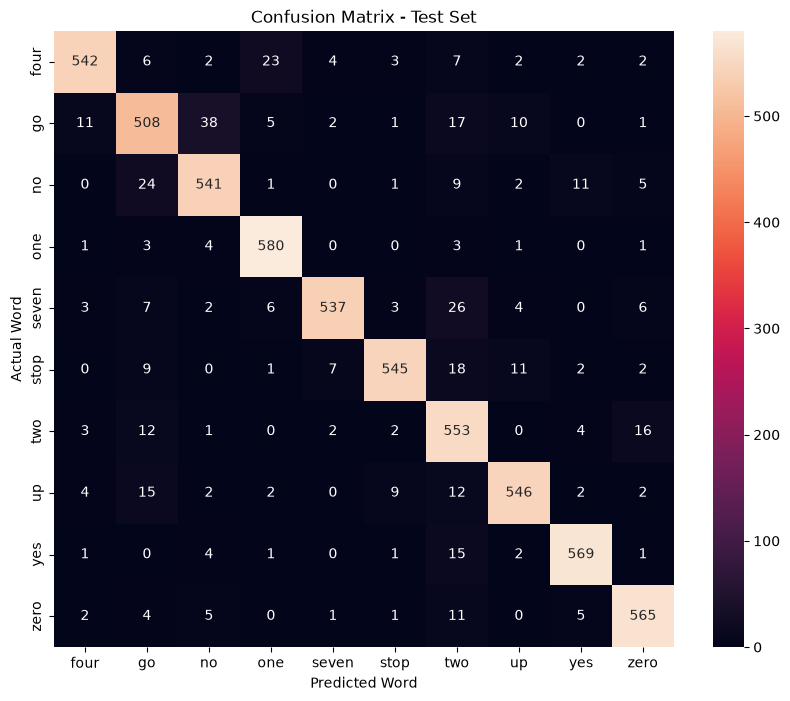

In [87]:
# Building Confusion Matrix with labels using a heatmap to visualize the performance of the LSTM model on the test set. 
# The confusion matrix shows the number of correct and incorrect predictions for each class, allowing for a better understanding of the model's performance across different words
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Word")
plt.ylabel("Actual Word")
plt.title("Confusion Matrix - Test Set")
plt.show()

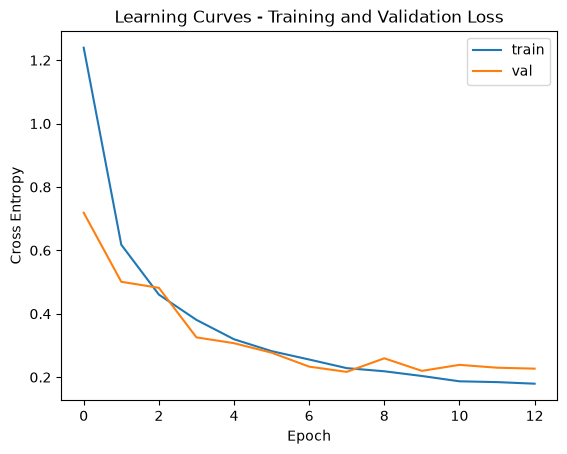

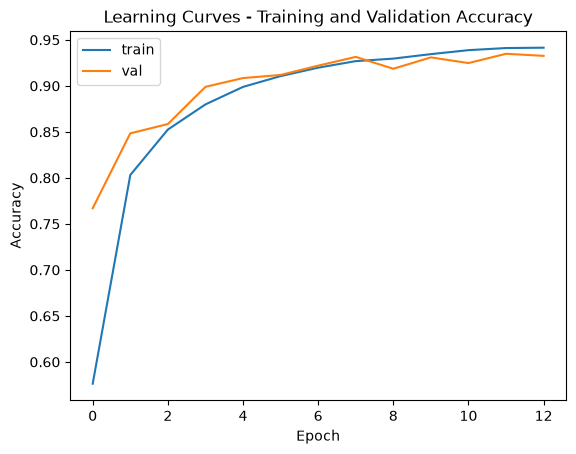

In [88]:
# Plot learning curves
plt.title('Learning Curves - Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.show()

# Plot learning curves
plt.title('Learning Curves - Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.plot(history.history['sparse_categorical_accuracy'], label='train')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='val')
plt.legend()
plt.show()

In [89]:
# Get the classification report to evaluate the performance of the LSTM model on the test set
print( classification_report( y_test, y_pred, target_names=label_encoder.classes_ ) )

              precision    recall  f1-score   support

        four       0.96      0.91      0.93       593
          go       0.86      0.86      0.86       593
          no       0.90      0.91      0.91       594
         one       0.94      0.98      0.96       593
       seven       0.97      0.90      0.94       594
        stop       0.96      0.92      0.94       595
         two       0.82      0.93      0.88       593
          up       0.94      0.92      0.93       594
         yes       0.96      0.96      0.96       594
        zero       0.94      0.95      0.95       594

    accuracy                           0.92      5937
   macro avg       0.93      0.92      0.92      5937
weighted avg       0.93      0.92      0.92      5937



As it can be seen while overall accuracy falls on 94% for Go class classification accuracy gets low and falls below 80%

## Saving fitted model and Label Encoder files

In [90]:
# Save the trained LSTM model to a file named "Word_classification_lstm.keras" for future use or deployment/testing with new data
model.save("Word_classification_lstm.keras")

# Save the encoded labels to a file named "label_encoder.pkl" for future use
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [91]:
# WAV_PATH = Path("TestingData_WAV")

# Setup (Assuming these exist based on your snippet context)
DATASET_PATH = Path("./TestingData_WAV") # Root folder
SELECTED_WORDS = None # Or a set of allowed words strings

records3 = []

# Use .rglob() for recursive search
# With recursive iterator:
print(f"Scanning {DATASET_PATH} recursively for .wav files...")
wav_files = list(DATASET_PATH.rglob("*.wav"))

print(f"Found total {len(wav_files)} files.")

for wav_file in wav_files:
    try:
        parts = wav_file.stem.split('_')
        
        if len(parts) >= 2:
            # Take the part after the first underscore
            word = parts[1] 
        else:
            # Fallback if filename doesn't contain an underscore
            print(f"Skipping: Filename does not match format expected for word extraction: {wav_file.name}")
            continue

        # Apply optional filter (kept from your original code)
        if SELECTED_WORDS is not None and word not in SELECTED_WORDS:
            continue

        # Exact loading and extraction
        audio, sample_rate = librosa.load(
            wav_file,
            sr=16000, # Resample to 16 kHz
            mono=True
        )
        duration = len(audio) / sample_rate
        
        # Remove leading and trailing silence
        audio, _ = librosa.effects.trim(
            audio,
            top_db=20
        )

        # MFCC extraction (20 features)
        mfcc = librosa.feature.mfcc(
            y=audio,
            sr=sample_rate,
            n_mfcc=20
        )

        records3.append({
            "word": word,
            "file": wav_file.name,
            # Added relative path so you know which subfolder it came from
            "relative_path": str(wav_file.relative_to(DATASET_PATH)), 
            "sample_rate": sample_rate,
            "duration": duration,
            "samples": len(audio),
            "mfcc": mfcc
        })

    except Exception as e:
        print(f"ERROR: {wav_file}")
        print(e)

print(f"Successfully processed {len(records3)} files.")

Scanning TestingData_WAV recursively for .wav files...
Found total 30 files.


Successfully processed 30 files.


In [92]:
df_new = pd.DataFrame(records3)

# Use existing encoder file to convert words to labels. 
# This ensures that the new data is encoded consistently with the training data.
le = joblib.load("label_encoder.pkl")

df_new['label'] = le.transform(df_new['word'].str.lower())  # Ensure consistent casing for label encoding

# Preview result
print(df_new[['word', 'label']].head(10))

    word  label
0   Four      0
1     Go      1
2     No      2
3    One      3
4  Seven      4
5   Stop      5
6    Two      6
7     Up      7
8    Yes      8
9   Zero      9


In [93]:
df_new['frames'] = df_new['mfcc'].apply(lambda x: len(x[0]))
df_new['frames'].describe()

count    30.000000
mean     19.366667
std       8.417893
min       8.000000
25%      13.250000
50%      17.000000
75%      24.500000
max      38.000000
Name: frames, dtype: float64

In [94]:
df_new.head()

,word,file,relative_path,sample_rate,duration,samples,mfcc,label,frames
0,Four,Sayuru_Four.wav,Malli\Sayuru_Four.wav,16000,1.706687,4608,"[[-360.5986, -278.01645, -242.34367, -232.1075...",0,10
1,Go,Sayuru_Go.wav,Malli\Sayuru_Go.wav,16000,1.706687,4608,"[[-324.64807, -228.33282, -183.82173, -179.721...",1,10
2,No,Sayuru_No.wav,Malli\Sayuru_No.wav,16000,1.834688,5632,"[[-421.73508, -344.75116, -310.55405, -289.611...",2,12
3,One,Sayuru_One.wav,Malli\Sayuru_One.wav,16000,1.920000,6144,"[[-433.9196, -352.45993, -298.54547, -254.5363...",3,13
4,Seven,Sayuru_Seven.wav,Malli\Sayuru_Seven.wav,16000,1.557375,8192,"[[-361.61685, -287.03513, -252.96153, -247.507...",4,17


In [95]:
MAX_FRAMES = 40
# Load fitted model
MODEL_PATH = "Word_classification_lstm.keras"
N_MFCC = 20 # Defined in extraction

# Load trained model
model = tf.keras.models.load_model(MODEL_PATH)

# Define preparation function
def prepare_mfcc(mfcc):
    mfcc = mfcc.T
    if mfcc.shape[0] < MAX_FRAMES:
        padding = np.zeros((MAX_FRAMES - mfcc.shape[0], N_MFCC))
        mfcc = np.vstack([mfcc, padding])
    # Trim if longer than maxframes (rare but safe)
    return mfcc[:MAX_FRAMES, :]

# Prepare X_new (Features)
X_new = np.array([prepare_mfcc(mfcc) for mfcc in df_new["mfcc"]])

# Prepare y_new (True Labels)
y_new = df_new["label"].values

# Verify shape
print(f"X_new shape: {X_new.shape}")

# Predict
predictions = model.predict(X_new)

# Convert predictions to predicted class index
y_pred_new = np.argmax(predictions, axis=1)


X_new shape: (30, 40, 20)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 471ms/step


In [96]:
# Confusion Matrix for new data
cm2 = confusion_matrix(y_new, y_pred_new)

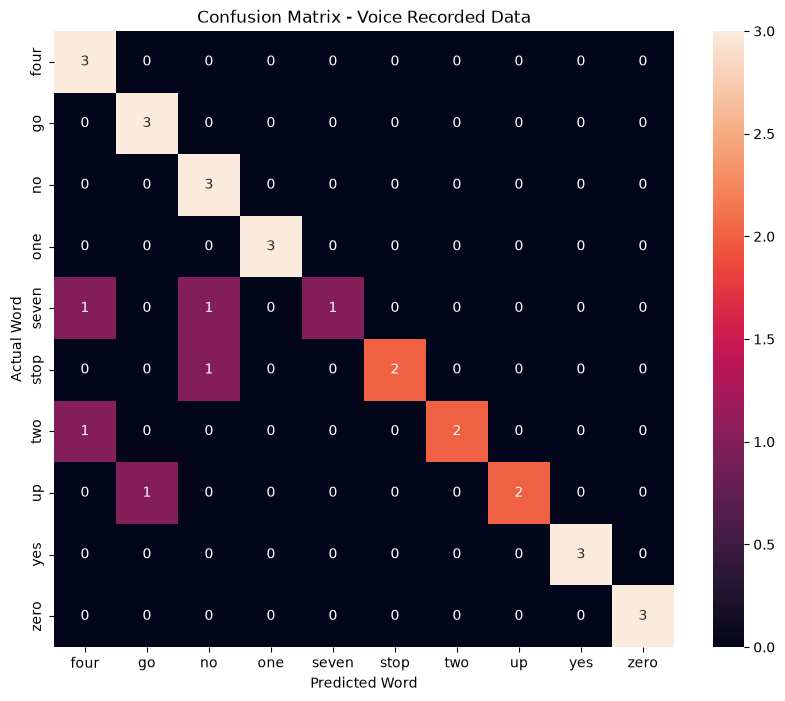

In [97]:
# The confusion matrix shows the number of correct and incorrect predictions for each class, allowing for a better understanding of the model's performance across different words
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm2,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted Word")
plt.ylabel("Actual Word")
plt.title("Confusion Matrix - Voice Recorded Data")
plt.show()

In [98]:
# Get the classification report to evaluate the performance of the LSTM model on the New Voice Recorded Data set
print( classification_report( y_new, y_pred_new, target_names=le.classes_ ) )

              precision    recall  f1-score   support

        four       0.60      1.00      0.75         3
          go       0.75      1.00      0.86         3
          no       0.60      1.00      0.75         3
         one       1.00      1.00      1.00         3
       seven       1.00      0.33      0.50         3
        stop       1.00      0.67      0.80         3
         two       1.00      0.67      0.80         3
          up       1.00      0.67      0.80         3
         yes       1.00      1.00      1.00         3
        zero       1.00      1.00      1.00         3

    accuracy                           0.83        30
   macro avg       0.89      0.83      0.83        30
weighted avg       0.90      0.83      0.83        30



In [99]:
# Debugging for sample rates and durations in training and testing datasets
print("TRAINING SAMPLE RATES")
print(df_selected["sample_rate"].value_counts())

print("\nTESTING SAMPLE RATES")
print(df_new["sample_rate"].value_counts())

print("\nTRAINING DURATIONS")
print(df_selected["duration"].describe())

print("\nTESTING DURATIONS")
print(df_new["duration"].describe())

TRAINING SAMPLE RATES
sample_rate
16000    23747
Name: count, dtype: int64

TESTING SAMPLE RATES
sample_rate
16000    30
Name: count, dtype: int64

TRAINING DURATIONS
count    23747.000000
mean         0.984034
std          0.061000
min          0.371563
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: duration, dtype: float64

TESTING DURATIONS
count    30.000000
mean      1.782608
std       0.322953
min       1.013500
25%       1.573375
50%       1.740094
75%       1.950469
max       2.373500
Name: duration, dtype: float64
